# 105_backtest — Leader–Follower Strategy Validation

**Author:** Wayne Kirk Schmidt  
**Email:** wayne.kirk.schmidt@gmail.com  

---

## Stage Purpose

This stage evaluates the statistical arbitrage hypotheses identified
in **004_strategy** by constructing and testing trade rules based on
leader–follower shock propagation.

Using the event-level signal structures produced in 004, we simulate
trades that exploit delayed reactions between assets and measure
the resulting performance characteristics.

The goal of this stage is **not discovery**, but **validation**:
to determine whether the observed signal structures translate into
repeatable, economically meaningful trading performance.

---

## Inputs (from 004_strategy)

Loaded from the pipeline manifest:

- `event_full_df.pkl`
  - Complete event-level dataset of leader–follower relationships
  - Includes:
    - leader coin (`r_coin`)
    - follower coin (`f_coin`)
    - leader direction (`r_sign`)
    - follower directional responses (`f_sign0/1/2`)
    - cumulative responses (`f_sum0/1/2`)

- `event_filtered_df.pkl`
  - Subset of events where follower response aligns directionally
  - Represents candidate signal events

- `event_strong_df.pkl`
  - High-confidence subset where multi-period agreement is observed
  - Represents strongest signal candidates

Additional inputs:

- `returns_full.pkl` (from 002_enrich)
  - Daily return series for all assets

- `price_wide.pkl` (from 002_enrich)
  - Wide-format price series for all assets

These artifacts represent the **frozen output of the strategy construction stage**.

---

## Core Tasks

This notebook performs the following steps:

1. **Signal Definition**
   - Select an input event set (full / filtered / strong)
   - Define trade direction from leader shock (`r_sign`)
   - Define mapping from event structure to executable trade

2. **Trade Construction**
   - Define entry timing (e.g. t+1)
   - Define exit timing (e.g. t+2 or t+3)
   - Map event dates to realized returns using `returns_full`
   - Construct event-level trade records

3. **Trade Simulation**
   - Aggregate event-level trades into a unified trade dataset
   - Apply execution assumptions (delay, cost)
   - Generate trade-level PnL series

4. **Performance Evaluation**
   - cumulative return
   - volatility
   - Sharpe ratio
   - win rate
   - max drawdown

5. **Validation Checks**
   - sensitivity to delay assumptions
   - robustness across event subsets
   - sanity comparison (e.g. randomized baseline)

---

## Outputs (Persisted in `output/005_backtest/`)

Artifacts produced by this stage:

- `trade_df.pkl`
  - Event-level trade log

- `daily_returns.pkl`
  - Aggregated daily return series

- `equity_curve.pkl`
  - Cumulative return curve

- `performance_summary.pkl`
  - Key performance metrics

- `stress_summary.pkl`
  - Performance across cost and delay scenarios

These outputs are registered in the **pipeline manifest** and form the
basis for final evaluation.

---

## Notes

This stage operates exclusively on artifacts generated in
**004_strategy** and **002_enrich**, ensuring that strategy construction
and validation remain cleanly separated within the pipeline.

All results must be reproducible from persisted artifacts.

---

## Design Principles

- **Deterministic pipeline**  
  Signals and trades are generated only from persisted upstream artifacts.

- **Separation of concerns**  
  Strategy construction (004) is distinct from validation (005).

- **Data integrity**  
  Trade construction must use realized returns (`returns_full`), not
  intermediate analysis structures.

- **Transparent mapping**  
  The transformation from event → trade → PnL must be explicit.

- **Artifact persistence**  
  All intermediate and final outputs are saved for inspection and reuse.

---

## Critical Constraint

005 must validate the **full set of signals produced by 004**, not a
manually reduced subset.


### 1. Imports and Environment Setup
### Provide the necessary imports required for to to proceed.   

In [2]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, UTC
import math
from pathlib import Path
import matplotlib.pyplot as plt

### 2. Prepare the environment for the notebook

In [3]:
startdate = "2023-01-01"
trading_days = 252
frequency = "1d"

universe = [
    "BTCUSDT",   # Bitcoin
    "ETHUSDT",   # Ethereum
    "BNBUSDT",   # Binance Coin
    "SOLUSDT",   # Solana
    "XRPUSDT",   # Ripple
    "ADAUSDT",   # Cardano
    "DOGEUSDT",  # Dogecoin
    "AVAXUSDT",  # Avalanche
    "LTCUSDT"    # Litecoin
]

execution_delay = [0, 1, 2, 3]
execution_cost_bps = [20, 30, 40]

stage_label = "005_backtest"

OUTPUT_ROOT = Path("../output")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MANIFEST_FILE = OUTPUT_ROOT / "manifest.pkl"

DOWNLOAD_DIR = OUTPUT_ROOT / "001_download"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

ENRICH_DIR = OUTPUT_ROOT / "002_enrich"
ENRICH_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_DIR = OUTPUT_ROOT / "003_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY_DIR = OUTPUT_ROOT / "004_strategy"
STRATEGY_DIR.mkdir(parents=True, exist_ok=True)

BACKTEST_DIR = OUTPUT_ROOT / "005_backtest"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

inspection_window = 20

sigma_threshold = 3

observation_window_length = 10
observation_window = range(1, observation_window_length + 1)

holding_period = 1


### 2.1 Loading the manifest pickle file

In [4]:
if MANIFEST_FILE.exists():
    manifest = pd.read_pickle(MANIFEST_FILE)
else:
    manifest = {}

manifest.setdefault(stage_label, {})

{}

### 3. Load the pickle files from the previous stage
We use these file contents for our analysis.

In [6]:
required_files = {
    "event_full_df": STRATEGY_DIR / "event_full_df.pkl",
    "event_filtered_df": STRATEGY_DIR / "event_filtered_df.pkl",
    "event_strong_df": STRATEGY_DIR / "event_strong_df.pkl",
    "returns_full": ENRICH_DIR / "returns_full.pkl",
    "price_wide": ENRICH_DIR / "price_wide.pkl",
}

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    raise FileNotFoundError(f"Missing required artifacts: {missing_files}")

# Load artifacts
event_full_df = pd.read_pickle(required_files["event_full_df"])
event_filtered_df = pd.read_pickle(required_files["event_filtered_df"])
event_strong_df = pd.read_pickle(required_files["event_strong_df"])

returns_full = pd.read_pickle(required_files["returns_full"])
price_wide = pd.read_pickle(required_files["price_wide"])

print("Artifacts loaded successfully")

Artifacts loaded successfully


### 4. Perform diagnostics on the pickle files that are uploaded

In [7]:
print("\n### DATA SHAPES ###")
print("event_full_df:", event_full_df.shape)
print("event_filtered_df:", event_filtered_df.shape)
print("event_strong_df:", event_strong_df.shape)
print("returns_full:", returns_full.shape)
print("price_wide:", price_wide.shape)

print("\n### COLUMN CHECK (event_full_df) ---")
print(list(event_full_df.columns))

# required schema check
required_cols = [
    "date", "r_coin", "r_sign", "f_coin",
    "f_sign0", "f_sign1", "f_sign2",
    "f_sum0", "f_sum1", "f_sum2"
]

missing = [c for c in required_cols if c not in event_full_df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Schema check passed")

print("\n### DATE ALIGNMENT ###")
print("event_full_df:", event_full_df["date"].min(), "→", event_full_df["date"].max())
print("returns_full:", returns_full.index.min(), "→", returns_full.index.max())

print("\n### COIN COVERAGE ###")
print("r_coins:", sorted(event_full_df["r_coin"].unique()))
print("f_coins:", sorted(event_full_df["f_coin"].unique()))

print("\n### SAMPLE ###")
display(event_filtered_df.head())


### DATA SHAPES ###
event_full_df: (832, 12)
event_filtered_df: (201, 12)
event_strong_df: (80, 13)
returns_full: (980, 9)
price_wide: (1175, 9)

### COLUMN CHECK (event_full_df) ---
['date', 'r_coin', 'r_sign', 'f_coin', 'f_sign0', 'f_sign1', 'f_sign2', 'f_sum0', 'f_sum1', 'f_sum2', 'match_sum1', 'match_sum2']
Schema check passed

### DATE ALIGNMENT ###
event_full_df: 2023-08-17 00:00:00 → 2026-02-05 00:00:00
returns_full: 2023-07-15 00:00:00+00:00 → 2026-03-20 00:00:00+00:00

### COIN COVERAGE ###
r_coins: ['ADAUSDT', 'AVAXUSDT', 'BNBUSDT', 'BTCUSDT', 'DOGEUSDT', 'ETHUSDT', 'LTCUSDT', 'SOLUSDT', 'XRPUSDT']
f_coins: ['ADAUSDT', 'AVAXUSDT', 'BNBUSDT', 'BTCUSDT', 'DOGEUSDT', 'ETHUSDT', 'LTCUSDT', 'SOLUSDT', 'XRPUSDT']

### SAMPLE ###


,date,r_coin,r_sign,f_coin,f_sign0,f_sign1,f_sign2,f_sum0,f_sum1,f_sum2,match_sum1,match_sum2
2,2023-08-17,ADAUSDT,-1,BTCUSDT,-1,-1,0,-1,-2,-2,True,True
10,2023-08-17,AVAXUSDT,-1,BTCUSDT,-1,-1,0,-1,-2,-2,True,True
18,2023-08-17,BNBUSDT,-1,BTCUSDT,-1,-1,0,-1,-2,-2,True,True
35,2023-08-17,ETHUSDT,-1,BTCUSDT,-1,-1,0,-1,-2,-2,True,True
43,2023-08-17,LTCUSDT,-1,BTCUSDT,-1,-1,0,-1,-2,-2,True,True


### 5. Assess the available potential trading signal

In [11]:
### Construction of potential Trading signal

source_df = event_filtered_df.copy()

### FIX: align timezone + normalize dates
returns_full.index = pd.to_datetime(returns_full.index).tz_convert(None)
source_df["date"] = pd.to_datetime(source_df["date"]).dt.tz_localize(None).dt.normalize()

### map the event_date to an integer index
date_to_idx = pd.Series(np.arange(len(returns_full.index)), index=returns_full.index)

### line up events to valid dates
source_df = source_df[source_df["date"].isin(date_to_idx.index)].copy()

source_df["base_idx"] = source_df["date"].map(date_to_idx)

### expand out including the delays
df = source_df.loc[source_df.index.repeat(len(execution_delay))].copy()
df["delay"] = np.tile(execution_delay, len(source_df))

### compute entry and exit indices
df["entry_idx"] = df["base_idx"] + df["delay"]
df["exit_idx"] = df["entry_idx"] + holding_period

### filter valid indices
max_idx = len(returns_full.index)
df = df[df["exit_idx"] < max_idx].copy()

### map indices → dates
returns_index = returns_full.index.to_numpy()

df["entry_date"] = returns_index[df["entry_idx"].values]
df["exit_date"] = returns_index[df["exit_idx"].values]

### Process Execution
col_idx = returns_full.columns.get_indexer(df["f_coin"])

df["exit_return"] = returns_full.to_numpy()[
    df["exit_idx"].values,
    col_idx
]

### Calculate Initial PNL
df["direction"] = df["r_sign"]
df["gross_pnl"] = df["direction"] * df["exit_return"]

# expand for costs
df = df.loc[df.index.repeat(len(execution_cost_bps))].copy()
df["cost_bps"] = np.tile(execution_cost_bps, len(df) // len(execution_cost_bps))

df["net_pnl"] = df["gross_pnl"] - (df["cost_bps"] / 10000)

### Assemble the final trade dataframe
trade_df = df[[
    "date", "entry_date", "exit_date",
    "r_coin", "f_coin",
    "direction", "delay", "cost_bps",
    "gross_pnl", "net_pnl"
]].rename(columns={"date": "event_date"})

print("Total trades:", len(trade_df))
display(trade_df.head())

Total trades: 9648


,event_date,entry_date,exit_date,r_coin,f_coin,direction,delay,cost_bps,gross_pnl,net_pnl
2,2023-08-17,2023-08-17,2023-08-18,ADAUSDT,BTCUSDT,-1,0,20,0.021397,0.019397
2,2023-08-17,2023-08-18,2023-08-19,ADAUSDT,BTCUSDT,-1,1,30,-0.001793,-0.004793
2,2023-08-17,2023-08-19,2023-08-20,ADAUSDT,BTCUSDT,-1,2,40,-0.003046,-0.007046
2,2023-08-17,2023-08-20,2023-08-21,ADAUSDT,BTCUSDT,-1,3,20,0.002438,0.000438
2,2023-08-17,2023-08-17,2023-08-18,ADAUSDT,BTCUSDT,-1,0,30,0.021397,0.018397


### 6. Initial Analysis


=== PERFORMANCE SUMMARY ===
total_return    3.209226
volatility      0.789316
sharpe          4.206469
max_drawdown   -0.176070
dtype: float64


<Axes: title={'center': 'Equity Curve'}, xlabel='entry_date'>

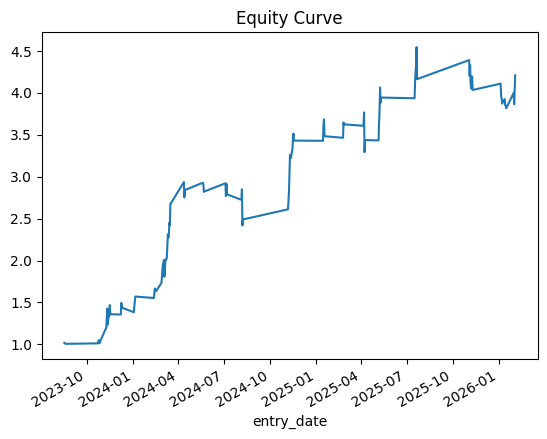

In [19]:
### AGGREGATE TO DAILY RETURNS
daily_returns = trade_df.groupby("entry_date")["net_pnl"].mean()
daily_returns = daily_returns.sort_index()

### EQUITY CURVE
equity_curve = (1 + daily_returns).cumprod()

### PERFORMANCE METRICS
total_return = equity_curve.iloc[-1] - 1

volatility = daily_returns.std() * np.sqrt(trading_days)

sharpe = (
    daily_returns.mean() /
    daily_returns.std()
) * np.sqrt(trading_days)

drawdown = equity_curve / equity_curve.cummax() - 1
max_drawdown = drawdown.min()

performance_summary = pd.Series({
    "total_return": total_return,
    "volatility": volatility,
    "sharpe": sharpe,
    "max_drawdown": max_drawdown
})

print("\n=== PERFORMANCE SUMMARY ===")
print(performance_summary)

### plot the curve
equity_curve.plot(title="Equity Curve")

### 7. Aggregation Sensetivity Test

In [20]:
def compute_performance(daily_returns, trading_days=trading_days):
    daily_returns = daily_returns.sort_index()
    equity_curve = (1 + daily_returns).cumprod()

    total_return = equity_curve.iloc[-1] - 1
    volatility = daily_returns.std() * np.sqrt(trading_days)
    sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(trading_days)
    drawdown = equity_curve / equity_curve.cummax() - 1
    max_drawdown = drawdown.min()

    return {
        "total_return": total_return,
        "volatility": volatility,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "days": len(daily_returns),
    }

daily_mean = trade_df.groupby("entry_date")["net_pnl"].mean()
daily_sum = trade_df.groupby("entry_date")["net_pnl"].sum()
daily_first = trade_df.groupby("entry_date")["net_pnl"].first()

perf_mean = compute_performance(daily_mean, trading_days)
perf_sum = compute_performance(daily_sum, trading_days)
perf_first = compute_performance(daily_first, trading_days)

aggregation_summary = pd.DataFrame(
    [perf_mean, perf_sum, perf_first],
    index=["mean", "sum", "first"]
)

print("=== AGGREGATION SENSITIVITY ===")
display(aggregation_summary)

=== AGGREGATION SENSITIVITY ===


,total_return,volatility,sharpe,max_drawdown,days
mean,3.209226e+00,0.789316,4.206469,-0.176070,121
sum,1.329839e+30,94.579380,3.076167,-225369.466151,121
first,2.896608e+00,0.931942,3.510549,-0.236813,121


### 8. Stress based on Cost as well as Delay

In [23]:
results = []

for delay in execution_delay:
    for cost in execution_cost_bps:

        subset = trade_df[
            (trade_df["delay"] == delay) &
            (trade_df["cost_bps"] == cost)
        ]

        if len(subset) == 0:
            continue

        daily_returns = subset.groupby("entry_date")["gross_pnl"].first()
        
        perf = compute_performance(daily_returns, trading_days)

        perf.update({
            "delay": delay,
            "cost_bps": cost,
            "trades": len(subset)
        })

        results.append(perf)

stress_df = pd.DataFrame(results)

print("=== STRESS TEST ===")
display(stress_df.sort_values("sharpe", ascending=False))

=== STRESS TEST ===


,total_return,volatility,sharpe,max_drawdown,days,delay,cost_bps,trades
0,3.773098,0.806643,14.232443,-0.041989,36,0,20,804
1,3.773098,0.806643,14.232443,-0.041989,36,0,30,804
2,3.773098,0.806643,14.232443,-0.041989,36,0,40,804
3,1.894220,1.056676,7.635766,-0.153629,36,1,20,804
4,1.894220,1.056676,7.635766,-0.153629,36,1,30,804
5,1.894220,1.056676,7.635766,-0.153629,36,1,40,804
6,-0.028806,0.987495,0.290603,-0.295084,36,2,20,804
7,-0.028806,0.987495,0.290603,-0.295084,36,2,30,804
8,-0.028806,0.987495,0.290603,-0.295084,36,2,40,804
9,-0.040499,0.962318,0.161956,-0.236080,36,3,20,804


### 9. Time based stress test. shift by one

In [24]:
subset_shifted = subset.copy()
subset_shifted["entry_date"] = subset_shifted["entry_date"] + pd.Timedelta(days=1)

results = []

for delay in execution_delay:
    for cost in execution_cost_bps:

        sub = subset_shifted[
            (subset_shifted["delay"] == delay) &
            (subset_shifted["cost_bps"] == cost)
        ]

        if len(sub) == 0:
            continue

        daily_returns = sub.groupby("entry_date")["gross_pnl"].first()

        perf = compute_performance(daily_returns, trading_days)

        perf.update({
            "delay": delay,
            "cost_bps": cost,
            "trades": len(sub)
        })

        results.append(perf)

stress_shift_df = pd.DataFrame(results)

print("=== SHIFTED STRESS TEST ===")
display(stress_shift_df.sort_values("sharpe", ascending=False))

=== SHIFTED STRESS TEST ===


,total_return,volatility,sharpe,max_drawdown,days,delay,cost_bps,trades
0,-0.040499,0.962318,0.161956,-0.23608,36,3,40,804


In [25]:
### Inspect continuation behavior directly from loaded data

df = event_full_df.copy()

# focus on negative shocks (dips)
df_neg = df[df["r_sign"] == -1].copy()

# 2-day continuation definition:
# both next two follower signs are also negative
df_neg["continue_2d"] = (
    (df_neg["f_sign1"] == -1) &
    (df_neg["f_sign2"] == -1)
)

# 1-day continuation (for reference)
df_neg["continue_1d"] = (df_neg["f_sign1"] == -1)

# summary stats
summary = {
    "total_events": len(df_neg),
    "1d_continuation_rate": df_neg["continue_1d"].mean(),
    "2d_continuation_rate": df_neg["continue_2d"].mean()
}

print("=== CONTINUATION SUMMARY ===")
print(summary)

# show concrete examples (not aggregated)
print("\n=== SAMPLE 2-DAY CONTINUATIONS ===")
display(df_neg[df_neg["continue_2d"]].head(20)[[
    "date", "r_coin", "f_coin",
    "r_sign",
    "f_sign1", "f_sign2",
    "f_sum1", "f_sum2"
]])

=== CONTINUATION SUMMARY ===
{'total_events': 352, '1d_continuation_rate': np.float64(0.13920454545454544), '2d_continuation_rate': np.float64(0.008522727272727272)}

=== SAMPLE 2-DAY CONTINUATIONS ===


,date,r_coin,f_coin,r_sign,f_sign1,f_sign2,f_sum1,f_sum2
491,2025-02-24,DOGEUSDT,BTCUSDT,-1,-1,-1,-2,-3
499,2025-02-24,ETHUSDT,BTCUSDT,-1,-1,-1,-2,-3
507,2025-02-24,SOLUSDT,BTCUSDT,-1,-1,-1,-2,-3
